Lab Exercise 2: Deep Feedforward Neural Network for Fashion MNIST Classification

Aim: The aim of this experiment is to design, implement, and evaluate a deep feedforward neural network (DFFNN) using PyTorch for classifying images from the Fashion MNIST dataset, and to understand how network depth, non-linear activations, loss functions, and gradient-based optimization influence supervised learning performance.

Tasks:

1. Load and preprocess Fashion MNIST data using PyTorch data loaders.

In [5]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [3]:
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.11MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 67.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.8MB/s]


In [4]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Here images are converted to tensors and pixel values are normalized.

2. Construct a multilayer feedforward neural network with at least three hidden layers.

3. Use ReLU activation in hidden layers and linear outputs for classification

In [6]:
class DeepNN(nn.Module):
    def __init__(self):
        super(DeepNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

Network has 3 hidden layers and fully connected feedforward architecture.

ReLU introduces non-linearity and output layer is linear. Softmax is implicitly applies by CrossEntropyLoss.

4. Train the network using cross entropy loss and an optimizer such as Adam or SGD.

In [7]:
model = DeepNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Here Adam optimizer updates weights using gradients

5. Monitor training loss and accuracy across epochs

In [8]:
num_epochs = 10

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch [1/10], Loss: 484.4978, Accuracy: 80.92%
Epoch [2/10], Loss: 356.6409, Accuracy: 86.20%
Epoch [3/10], Loss: 316.4499, Accuracy: 87.61%
Epoch [4/10], Loss: 295.6320, Accuracy: 88.38%
Epoch [5/10], Loss: 278.2417, Accuracy: 89.06%
Epoch [6/10], Loss: 262.2798, Accuracy: 89.53%
Epoch [7/10], Loss: 248.2477, Accuracy: 90.10%
Epoch [8/10], Loss: 235.6907, Accuracy: 90.64%
Epoch [9/10], Loss: 224.2636, Accuracy: 91.06%
Epoch [10/10], Loss: 216.9181, Accuracy: 91.35%


Here accuracy is computed in every epoch and printed to observe trend.


From observed behaviour, Training loss consistently decreases and Training accuracy steadily increases which indicates proper learning and convergence. This means model benefits from more weight updates

6. Monitor training loss and accuracy across epochs

In [9]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 88.20%


Test accuracy is lower than training accuracy as test data is unseen and slight generalization gap exists.This small gap between training and test accuracy is expected in deep networks and shows that the model has learned useful features without memorizing the training data. This indicates good generalization with mild overfitting.

7. Explain the role of forward pass, backward pass and gradient updates.

The forward pass sends input data through the network to produce predictions, using linear operations and activation functions like ReLU to learn patterns. The backward pass computes errors and finds gradients for each weight using backpropagation. During gradient updates, an optimizer such as Adam or SGD adjusts the weights using these gradients to reduce the loss. Repeating this process over multiple epochs helps the model learn and improve its performance on unseen data.

8. Interpret the impact of hyperparameters such as learning rate, batch size and number of epochs.


Changing number of epochs to 5

In [10]:
num_epochs = 5

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch [1/5], Loss: 205.0128, Accuracy: 91.70%
Epoch [2/5], Loss: 196.7980, Accuracy: 92.07%
Epoch [3/5], Loss: 185.1991, Accuracy: 92.47%
Epoch [4/5], Loss: 182.3097, Accuracy: 92.61%
Epoch [5/5], Loss: 171.6895, Accuracy: 93.06%


When the number of epochs is reduced to 5, the model still learns effectively, as shown by the steady decrease in training loss and the increase in training accuracy. This means the network can learn useful features quickly, and the training process remains stable even with fewer training iterations.

In [11]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 88.62%


When the test accuracy is lower than the training accuracy, it shows that the model has not generalized well to unseen data. With fewer epochs, the model gets less time to adjust and refine its weights, which results in slightly weaker performance on the test set. While using fewer epochs reduces training time and computation, it can cause underfitting or incomplete learning. This shows that the number of epochs directly affects how well the model learns—too few epochs limit generalization, while a sufficient number helps achieve a better balance between learning and generalization.

Changing number of epochs to 15

In [19]:
num_epochs = 15

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch [1/15], Loss: 31.5528, Accuracy: 97.37%
Epoch [2/15], Loss: 29.9350, Accuracy: 97.59%
Epoch [3/15], Loss: 28.3206, Accuracy: 97.66%
Epoch [4/15], Loss: 26.6038, Accuracy: 97.85%
Epoch [5/15], Loss: 25.7359, Accuracy: 97.92%
Epoch [6/15], Loss: 26.7759, Accuracy: 97.84%
Epoch [7/15], Loss: 25.0556, Accuracy: 97.98%
Epoch [8/15], Loss: 21.9550, Accuracy: 98.17%
Epoch [9/15], Loss: 24.6219, Accuracy: 97.98%
Epoch [10/15], Loss: 26.3180, Accuracy: 97.87%
Epoch [11/15], Loss: 20.6652, Accuracy: 98.37%
Epoch [12/15], Loss: 22.1111, Accuracy: 98.22%
Epoch [13/15], Loss: 22.0018, Accuracy: 98.18%
Epoch [14/15], Loss: 20.0451, Accuracy: 98.37%
Epoch [15/15], Loss: 18.8210, Accuracy: 98.47%


In [20]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 88.76%


Increasing the number of epochs to 15 makes the model learn the training data very well, as shown by the high training accuracy and low training loss. However, the test accuracy improves only slightly to 88.76%, which means the model is mainly memorizing the training data instead of learning patterns that generalize well. The larger difference between training and test accuracy indicates overfitting. This shows that while increasing epochs improves training performance, training for too long gives little benefit on unseen data and can reduce generalization.

Changing batch size to 32

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [14]:
num_epochs = 10

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch [1/10], Loss: 408.5535, Accuracy: 91.77%
Epoch [2/10], Loss: 363.6377, Accuracy: 92.61%
Epoch [3/10], Loss: 354.4709, Accuracy: 92.81%
Epoch [4/10], Loss: 342.5124, Accuracy: 92.95%
Epoch [5/10], Loss: 326.2543, Accuracy: 93.39%
Epoch [6/10], Loss: 321.7693, Accuracy: 93.54%
Epoch [7/10], Loss: 305.3547, Accuracy: 93.80%
Epoch [8/10], Loss: 304.7271, Accuracy: 93.96%
Epoch [9/10], Loss: 289.3195, Accuracy: 94.08%
Epoch [10/10], Loss: 288.1896, Accuracy: 94.19%


In [15]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 88.21%


Reducing the batch size to 32 allows the model to update its weights more frequently, which leads to a steady decrease in training loss and an increase in training accuracy to 94.19%. Smaller batches add some randomness to the training process, which can help the model learn better from the training data. However, the test accuracy remains almost the same at 88.21%, showing that the smaller batch size does not greatly improve performance on unseen data. This means that while a smaller batch size can improve training behavior, it does not always result in better generalization.

Changing batch size to 128

In [16]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [17]:
num_epochs = 10

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch [1/10], Loss: 45.1948, Accuracy: 96.34%
Epoch [2/10], Loss: 37.6924, Accuracy: 96.96%
Epoch [3/10], Loss: 36.4326, Accuracy: 96.99%
Epoch [4/10], Loss: 36.1629, Accuracy: 97.01%
Epoch [5/10], Loss: 35.7979, Accuracy: 97.08%
Epoch [6/10], Loss: 35.5901, Accuracy: 97.02%
Epoch [7/10], Loss: 34.1105, Accuracy: 97.15%
Epoch [8/10], Loss: 33.6625, Accuracy: 97.28%
Epoch [9/10], Loss: 32.7935, Accuracy: 97.35%
Epoch [10/10], Loss: 31.6588, Accuracy: 97.41%


In [18]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 89.15%


Increasing the batch size to 128 makes the training more smooth and stable. This is seen from the steady decrease in loss and the gradual increase in training accuracy to 97.41%. Larger batches give more stable gradient updates, which helps the model converge in a steady manner. The test accuracy of 89.15% shows slightly better generalization compared to smaller batch sizes. However, because the updates are less noisy, learning can be slower, meaning larger batch sizes improve stability but reduce the natural regularization provided by smaller batches.

Changing lr to 0.01

In [21]:
model = DeepNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [22]:
num_epochs = 10

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch [1/10], Loss: 261.2348, Accuracy: 80.02%
Epoch [2/10], Loss: 202.4257, Accuracy: 84.40%
Epoch [3/10], Loss: 187.8908, Accuracy: 85.65%
Epoch [4/10], Loss: 179.9884, Accuracy: 86.22%
Epoch [5/10], Loss: 174.7135, Accuracy: 86.62%
Epoch [6/10], Loss: 164.8907, Accuracy: 87.33%
Epoch [7/10], Loss: 166.4869, Accuracy: 87.39%
Epoch [8/10], Loss: 164.0902, Accuracy: 87.46%
Epoch [9/10], Loss: 159.2307, Accuracy: 87.72%
Epoch [10/10], Loss: 158.9182, Accuracy: 87.95%


In [23]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 84.71%


Increasing the learning rate to 0.01 makes the model learn too aggressively. Although the loss reduces faster at the beginning, the model does not learn properly and ends up with a lower training accuracy of 87.95%. The test accuracy drops to 84.71%, showing poor generalization. This happens because a large learning rate causes the optimizer to overshoot the optimal values instead of settling at the best solution. Overall, a high learning rate speeds up early learning but reduces training stability and final performance.

Changing lr to 0.0001

In [24]:
model = DeepNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [25]:
num_epochs = 10

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch [1/10], Loss: 435.1538, Accuracy: 69.29%
Epoch [2/10], Loss: 236.5946, Accuracy: 82.03%
Epoch [3/10], Loss: 211.3236, Accuracy: 83.92%
Epoch [4/10], Loss: 197.6318, Accuracy: 84.91%
Epoch [5/10], Loss: 187.6526, Accuracy: 85.74%
Epoch [6/10], Loss: 179.8818, Accuracy: 86.33%
Epoch [7/10], Loss: 173.2167, Accuracy: 86.81%
Epoch [8/10], Loss: 168.1160, Accuracy: 87.06%
Epoch [9/10], Loss: 163.2073, Accuracy: 87.54%
Epoch [10/10], Loss: 159.1729, Accuracy: 87.78%


In [26]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 86.58%


Reducing the learning rate to 0.0001 makes the model learn more slowly. This is seen from the high loss at the beginning and the gradual increase in training accuracy from 69.29% to 87.78% over 10 epochs. Because the learning rate is very small, the optimizer updates the weights in very small steps, which makes learning stable but slow. The test accuracy of 86.58%, which is lower than with a higher learning rate, shows that the model has not fully learned within the limited number of epochs. This means that a very low learning rate needs more epochs to reach better performance.

Using SDG optimizer

In [27]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [28]:
num_epochs = 10

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch [1/10], Loss: 152.2434, Accuracy: 88.36%
Epoch [2/10], Loss: 151.5458, Accuracy: 88.42%
Epoch [3/10], Loss: 151.1765, Accuracy: 88.37%
Epoch [4/10], Loss: 150.9509, Accuracy: 88.43%
Epoch [5/10], Loss: 150.7761, Accuracy: 88.45%
Epoch [6/10], Loss: 150.4685, Accuracy: 88.47%
Epoch [7/10], Loss: 150.2291, Accuracy: 88.52%
Epoch [8/10], Loss: 150.1118, Accuracy: 88.52%
Epoch [9/10], Loss: 149.9887, Accuracy: 88.50%
Epoch [10/10], Loss: 149.8558, Accuracy: 88.52%


In [29]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 86.90%


Using the SGD optimizer, the model learns slowly and steadily. This can be seen from the loss decreasing very gradually and the training accuracy staying almost the same at around 88.5% in each epoch. Unlike Adam, which automatically adjusts the learning rate, SGD uses a fixed learning rate, so the weight updates are smaller and learning is slower. The test accuracy of 86.90% shows that the model generalizes reasonably well, but its performance is lower compared to Adam for the same number of epochs. This means that SGD usually needs more training epochs or momentum to achieve better results.

Advanced Task 1:

In [31]:
import torch
import torch.nn as nn

class ConfigurableNN(nn.Module):
    def __init__(self, hidden_layers):
        super(ConfigurableNN, self).__init__()

        layers = []
        input_size = 784

        for h in hidden_layers:
            layers.append(nn.Linear(input_size, h))
            layers.append(nn.ReLU())
            input_size = h

        layers.append(nn.Linear(input_size, 10))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [32]:
def train_and_test(hidden_layers, train_loader, test_loader, epochs=10, lr=0.001):
    model = ConfigurableNN(hidden_layers)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images = images.view(images.size(0), -1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        losses.append(total_loss / len(train_loader))

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(images.size(0), -1)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return losses[-1], 100 * correct / total


In [33]:
configs = {
    "1 Hidden Layer": [128],
    "3 Hidden Layers": [256, 128, 64],
    "5 Hidden Layers": [512, 256, 128, 64, 32]
}

results = {}

for name, layers in configs.items():
    loss, acc = train_and_test(layers, train_loader, test_loader)
    results[name] = (loss, acc)

In [34]:
for name, (loss, acc) in results.items():
    print(f"{name} -> Final Training Loss: {loss:.4f}, Test Accuracy: {acc:.2f}%")

1 Hidden Layer -> Final Training Loss: 0.2508, Test Accuracy: 87.85%
3 Hidden Layers -> Final Training Loss: 0.2308, Test Accuracy: 87.91%
5 Hidden Layers -> Final Training Loss: 0.2405, Test Accuracy: 87.92%


The results show that increasing the number of hidden layers slightly reduces training loss, indicating better fitting of the training data. However, the test accuracy remains almost the same for all models, showing that deeper networks do not significantly improve generalization for this task. This suggests that beyond a certain depth, adding more layers provides diminishing returns and may increase complexity without meaningful performance gains.

Advanced task 2:

In [35]:
class ActivationNN(nn.Module):
    def __init__(self, activation_fn):
        super(ActivationNN, self).__init__()

        if activation_fn == "relu":
            act = nn.ReLU()
        elif activation_fn == "sigmoid":
            act = nn.Sigmoid()
        elif activation_fn == "tanh":
            act = nn.Tanh()
        elif activation_fn == "leaky_relu":
            act = nn.LeakyReLU(0.01)

        self.model = nn.Sequential(
            nn.Linear(784, 256), act,
            nn.Linear(256, 128), act,
            nn.Linear(128, 64), act,
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [36]:
def train_activation_model(activation, train_loader, test_loader, epochs=10):
    model = ActivationNN(activation)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images = images.view(images.size(0), -1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(images.size(0), -1)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total


In [37]:
activations = ["relu", "sigmoid", "tanh", "leaky_relu"]
results = {}

for act in activations:
    acc = train_activation_model(act, train_loader, test_loader)
    results[act] = acc

In [44]:
for act, acc in results.items():
    print(f"{act} activation -> Test Accuracy: {acc:.2f}%")

relu activation -> Test Accuracy: 88.24%
sigmoid activation -> Test Accuracy: 87.38%
tanh activation -> Test Accuracy: 87.45%
leaky_relu activation -> Test Accuracy: 88.27%


The results show that ReLU and Leaky ReLU perform slightly better than Sigmoid and Tanh for this deep network. ReLU and Leaky ReLU allow faster and more stable learning, which leads to higher test accuracy. Sigmoid and Tanh give lower accuracy because they can slow down learning in deeper networks. Overall, Leaky ReLU gives the best performance, followed closely by ReLU.

Advanced task 3

In [38]:
class VisualizableNN(nn.Module):
    def __init__(self):
        super(VisualizableNN, self).__init__()

        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        a1 = self.relu(self.fc1(x))
        a2 = self.relu(self.fc2(a1))
        a3 = self.relu(self.fc3(a2))
        out = self.fc4(a3)
        return out, a1, a2, a3

In [42]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))
image = images[0].view(1, -1)

model = VisualizableNN()
model.eval()
with torch.no_grad():
    output, act1, act2, act3 = model(image)

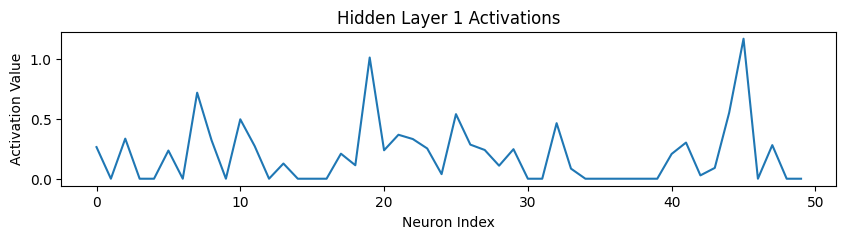

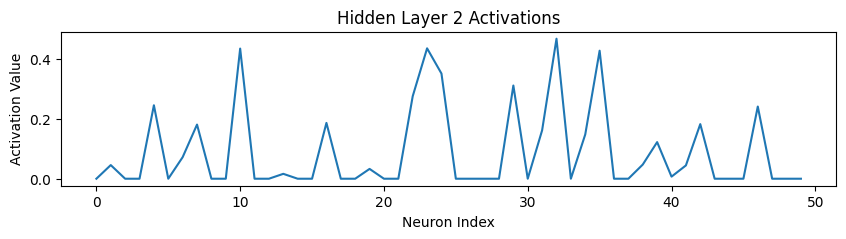

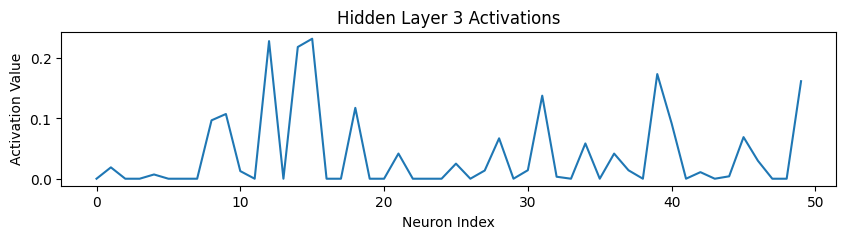

In [43]:
def plot_activations(activations, title):
    plt.figure(figsize=(10, 2))
    plt.plot(activations[0][:50].cpu())
    plt.title(title)
    plt.xlabel("Neuron Index")
    plt.ylabel("Activation Value")
    plt.show()

plot_activations(act1, "Hidden Layer 1 Activations")
plot_activations(act2, "Hidden Layer 2 Activations")
plot_activations(act3, "Hidden Layer 3 Activations")

The activation plots show that Hidden Layer 1 has many active neurons with higher values, indicating that it learns basic features such as edges and simple patterns from the input image.

In Hidden Layer 2, fewer neurons are strongly activated, showing that the network is combining these basic features into more meaningful patterns.

Hidden Layer 3 has very sparse activations, meaning only a few neurons respond strongly, which indicates that the network is focusing on high-level, class-specific features.

Thus, as depth increases, neuron activations become sparser and more selective, showing hierarchical feature learning in the network.